In [1]:
## CHAPTER 3 신경망
# 3.1.1 신경망의 예
# 입력층 (0층, input layer), 은닉층(1층, hidden layer), 출력층(2층, output layer)
# 화살표 = 엣지 = 가중치  = weight
# 전방신경망, 순환신경망, 얕은 신경망, 깊은 신경망, 결정론 신경망, 스토캐스틱 신경망
# 3.1.2 퍼셉트론 복습
# h(x) 활성화 함수(activation function), y = h(w1x1 + w2x2 + b) -> a = b + w1x2 + w2x2 -> h(a)
import numpy as np
#a = b + np.sum(w*x)
def h(a):   #step function
    if a > 0: return 1
    else: return 0
# perceptron 의 구조 
#입력층과 출력층을 가짐. (입력층은 연산을 하지 않으므로 perceptron은 단일 층 구조)
# 출력층은 하나의 노드
# 특정값과 가중치를 곱한 결과를 모두 더하여 s, 활성화함수 t를 적용
w = np.array([1,1])
b = -0.5
X = np.array([[0,0],[0,1],[1,0],[1,1]])
for x in X:
    a = b + np.sum(x*w)
    print(h(a))
print()
b= -1.5
for x in X:
    a = b + np.sum(x*w)
    print(h(a))
#목적함수 설계 매개변수 집합은 theta = {w}
# 목적함수 J(theta), J(w)
# J >= 0, w 가 최적이면 J(w) = 0, 많이 틀리면 J(w) 증가 

0
1
1
1

0
0
0
1


In [2]:
# 3.1.3 활성화 함수 등장
# 가중치가 곱해진 입력 신호의 총합을 계산하고, 그 합을 활성화 함수에 입력해 결과를 내는 2단계로 처리
# w1, w2 = 1,1
# s = b + w1*x1 + w2*x2
# y = t(s)
#계단함수
def step_01(s):
    if s >= 0: return 1
    else: return 0
def step_11(s):
    if s >= 0: return 1
    else: -1 
#로지스틱 시그모이드
def logistic_sigmoid(s):
    return 1/(1+np.exp(-a*s))
#하이퍼볼릭 탄젠트
def tanh(s):
    return (2/(1+np.exp(-a*s))) -1 
#소프트플러스
def softplus(s):
    return np.log(1 + np.exp(s))
#렉티파이어(ReLU)
def ReLU(s):
    return max(0,s)

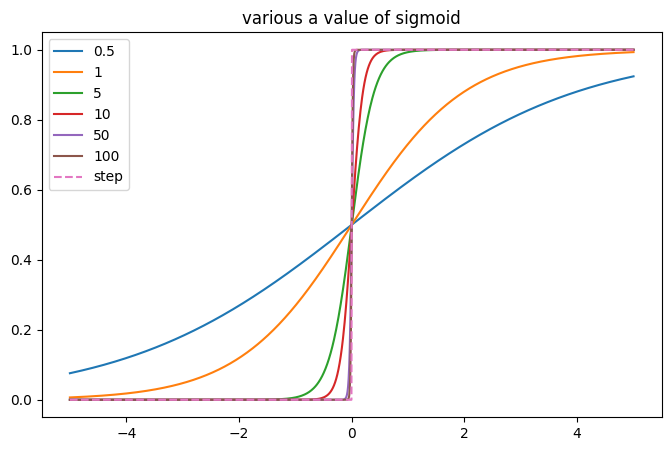

In [3]:
# 3.1.3 문제 : 로지스틱 시그모이드의 a값이 커짐에 따라, step function과 비슷한지 나타내라
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x,a=1):
    return 1/(1+np.exp(-a*x))

x = np.linspace(-5,5,1000)
plt.figure(figsize=(8,5))
#sigmoid
for a in [0.5, 1, 5, 10, 50, 100]:
    plt.plot(x, sigmoid(x,a), label = a)





step = np.where(x>=0, 1, 0)
plt.plot(x, step, linestyle = '--' ,label = 'step')

plt.legend()
plt.title('various a value of sigmoid')
plt.show()

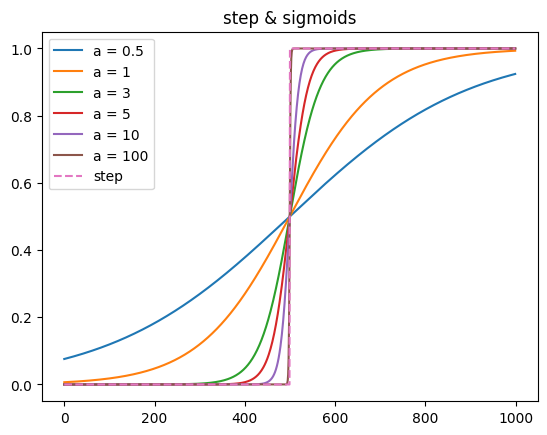

In [4]:
# 복기
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5,5,1000)


# sigmoid function
def sigmoid(a):
    return (1/(1+np.exp(-a*x)))
for a in [0.5,1,3,5,10,100]:
    plt.plot(sigmoid(a), label = f'a = {a}')

#step function
step = np.where(x>=0, 1, 0)
plt.plot(step, label ='step', linestyle = '--')


plt.legend()
plt.title('step & sigmoids')
plt.show()


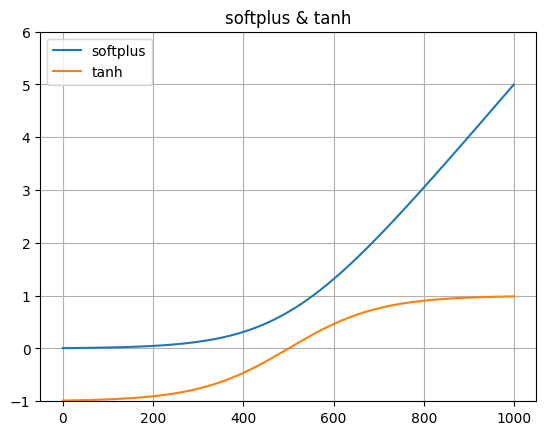

In [5]:
# softplus(x), tanh(x) 
import numpy as np
import matplotlib.pyplot as plt
a = 1 
x = np.arange(-5,5,0.01)

#softplus
def softplus(x):
    return np.log(1+np.exp(x))
plt.plot(softplus(x), label = 'softplus')

#tanh
def tanh(x):
    return (2/(1+np.exp(-a*x)) -1)
plt.plot(tanh(x), label = 'tanh')

plt.ylim(-1,6)
plt.grid(True)
plt.title('softplus & tanh')
plt.legend()
plt.show()

In [6]:
# 3.2.2 계단함수 2가지 구현하기. 형식이 안맞아 에러가 뜨는데 어떤 에러가 뜨는지
import numpy as np

def step1(x):
    if x >= 0: return 1
    else: return 0
x1 = np.array([-1.0])
y1 = step1(x1)
print(y1)

def step2(x):
    y2 = x > 0
    return y2.astype(np.int32)

x2 = np.array([-1.0,1.0,2.0])
y2 = step2(x2)
print(y2)

#print(step1(x2))
# step1(x2) -> ValueError: 타입이 아니라 배열 원소 수 때문
# x2 >= 0 은 array([False, True, True]) 반환 -> if는 단일 bool만 판단 가능
# x1은 원소 1개라 단일 bool로 평가되어 통과, x2는 3개라 불가

0
[0 1 1]


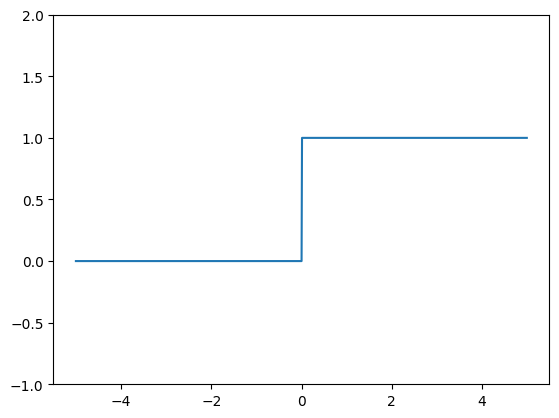

In [7]:
# 3.2.3 계단 함수 그래프 
import numpy as np
import matplotlib.pyplot as plt

def step2(x):
    y = x > 0
    return y.astype(np.int64)

x = np.arange(-5,5,0.01)
y = step2(x)
plt.plot(x, y)
plt.ylim(-1,2)
plt.show()

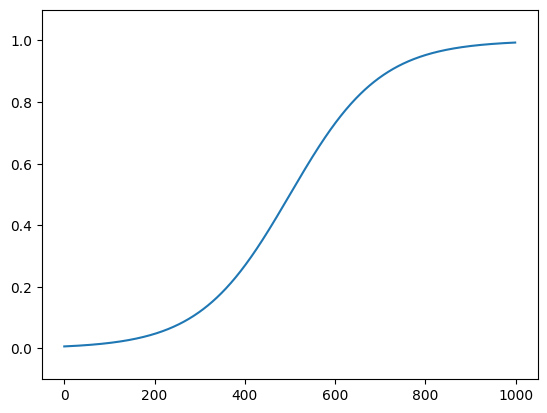

In [8]:
# 3.2.4 시그모이드 
# 3.2.5 시그모이드와 계단 함수의 비교. sigmoid는 부드러운 연속적인 곡선(미분가능), 계단함수는 비연속적(미분불가능)
import numpy as np
import matplotlib.pyplot as plt
a = 1
x = np.arange(-5,5,0.01)
#sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-a*x))
plt.plot(sigmoid(x), label = 'sigmoid')
plt.ylim(-0.1,1.1)
plt.show()

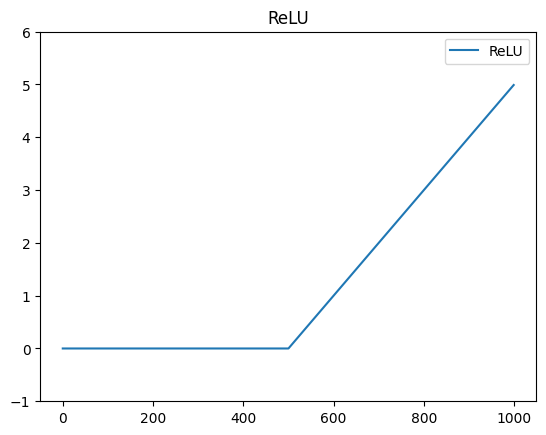

In [9]:
# 3.2.6 비선형 함수 
# 계단 함수와 시그모이드 함수의 공통점으로 둘다 비선형 함수 
# 변환기에 출력값이 입력값의 상수배만큼 변하는 함수를 선형함수라고함.
# 선형 예) f(x) = ax + b, a,b는 상수, 직선
# 비선형 예) 선형이 아닌 함수, 즉 직선 1개로 그릴 수 없는 함수, 곡선

# 3.2.7 ReLU 함수
import numpy as np
import matplotlib.pyplot as plt

#ReLU
def ReLU(x):
    return np.maximum(0,x)
x = np.arange(-5,5,0.01)

plt.plot(ReLU(x), label = 'ReLU')
plt.ylim(-1,6)
plt.legend()
plt.title("ReLU")
plt.show()

In [10]:
# 3.3 다차원 배열 (vector, matrix)
# Vector 샘플의 여러 특징을 Featur Vector(특징 벡터)로 표현 
# Matrix 여러개의 벡터로 구성, 훈련집합을 담은 행렬을 Design matrix(설계행렬)이라 부름
# 배열의 차원 수: np.ndim()
import numpy as np
a = np.array([1,2,3,4])
print(a)
print(np.ndim(a))
print(a.shape)
print(a.shape[0])
b = np.array([[1,2],[3,4],[5,6]])
print(b)
print(np.ndim(b))
print(b.shape)

[1 2 3 4]
1
(4,)
4
[[1 2]
 [3 4]
 [5 6]]
2
(3, 2)


In [11]:
# 3.3.2 행렬곱
# 행렬곱에 대응하는 차원의 원소 수를 일치 시켜라 3 X 2 * 2 X 4 =  3 X 4
# 3 X 2 * 2 = 3
import numpy as np
import matplotlib.pyplot as plt


a = np.array([[1,2],[3,4]])
b = np.array([[1,3],[2,4]])
print(a, '\n',a.shape,'\n')
print(b, '\n',b.shape, '\n')

print('np.dot(a,b)', '\n', np.dot(a,b))

[[1 2]
 [3 4]] 
 (2, 2) 

[[1 3]
 [2 4]] 
 (2, 2) 

np.dot(a,b) 
 [[ 5 11]
 [11 25]]


In [12]:
# 3.3.3 신경망에서의 행렬곱 
# x, w, y / x와 w의 대응하는 차원의 원소 수가 같아야함. 다차원 배열의 스칼라곱을 np.dot을 통해 한번에 계산 가능
# 교환 법칙 AB != BA
# 분배 법칙 A(B + C) = AB + AC
# 결합 법칙 성립 A(BC) = (AB)C


x = np.array([1,2])
w = np.array([[1,2,3,],[4,5,6]])
y = np.dot(x,w)
print(x.shape, '\n', x, '\n')
print(w.shape, '\n', w, '\n')
print('np.dot(x,w)', '\n', y)

# 3차원 Tensor
tensor = np.array([[[1,1],[1,1]],[[2,2],[2,2]],[[3,3],[3,3]]])
print(tensor)

(2,) 
 [1 2] 

(2, 3) 
 [[1 2 3]
 [4 5 6]] 

np.dot(x,w) 
 [ 9 12 15]
[[[1 1]
  [1 1]]

 [[2 2]
  [2 2]]

 [[3 3]
  [3 3]]]


In [13]:
# 3.3 다차원 배열 norm, similiarity
# vector n차 놈
# 2차 놈 : Euclidean norm
import math
import numpy as np
v = np.array([3,4])
# 2차 유클리드
def norm_2dim(vector):
    return math.sqrt(sum(x**2 for x in vector))
print(norm_2dim(v))

matrix = np.array([[1,2,3],[4,5,6],[7,8,9]])
# 행렬 프로베니우스 놈 
def frobenius_norm(matrix):
    return math.sqrt(sum(r**2 for row in matrix for r in row))

print(frobenius_norm(matrix))

5.0
16.881943016134134


In [14]:
# 3.3 3차 놈
import math
import numpy as np

v = np.array([2,3,6])
def norm_n_dim(v, n):
    return sum(i**n for i in v)**(1/n)
print('3차 놈 : ',norm_n_dim(v, 3))

# cos similarity
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

a = np.array([[1,2,3]])
b = np.array([[2,3,6]])
print(cosine_similarity(a,b))


a = np.array([1,2,3])
b = np.array([2,3,6])
def cos_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
print(cos_similarity(a,b))

3차 놈 :  6.307993548663267
[[0.99268461]]
0.9926846128175763


In [15]:
# 3.4 3층 신경망
# 0,1,2,3 
import numpy as np

input_layer = np.array([1,2])
print(input_layer)
w1 = np.array([[2,2,2],[2,1,2]])
hidden1 = np.dot(input_layer, w1)
print(hidden1)
w2 = np.array([[0.5,0.5],[0.5,0.5],[0.5,0.5]])
hidden2 = np.dot(hidden1, w2)
print(hidden2)
w3 = np.array([[0.5,0.5],[0.5,0.5]])
output_layer = np.dot(hidden2,w3)
print(output_layer)

[1 2]
[6 4 6]
[8. 8.]
[8. 8.]


In [16]:
# 3.4.2 각 층 신호 전달 구현 + bias
import numpy as np
a = 1
def sigmoid(x):
    return 1/(1+np.exp(-a*x))

x = np.array([1,2])
print('x :','\n',x)
w1 = np.array([[1,1,1],[0.5,1,0.5]])
print('w1 :', '\n',w)
b1 = np.array([0.1,0.1,0.1])
print('b1 :', '\n',b1)
a1 = np.dot(x,w1)+b1
print('a1 :', '\n', a1)
hidden1 = sigmoid(a1)
print('hidden1 : ', '\n', hidden1)

w2 =  np.array([[0.1,0.5],[0.1,0.5],[0.1,0.5]])
print('w2', '\n', w2)
b2 = np.array([0.3,0.3])
print('b2', '\n', b2)
a2 = np.dot(hidden1,w2)+b2
print('a2', '\n', a2)
hidden2 = sigmoid(a2)
print('hidden2', '\n', hidden2)

x : 
 [1 2]
w1 : 
 [[1 2 3]
 [4 5 6]]
b1 : 
 [0.1 0.1 0.1]
a1 : 
 [2.1 3.1 2.1]
hidden1 :  
 [0.89090318 0.95689275 0.89090318]
w2 
 [[0.1 0.5]
 [0.1 0.5]
 [0.1 0.5]]
b2 
 [0.3 0.3]
a2 
 [0.57386991 1.66934955]
hidden2 
 [0.63965566 0.84148908]


In [17]:
# 3.5.1 항등 함수와 소프트맥수 함수 구하기 
# N = 출력층 뉴런수, Yk는 그중 k번째 출력 
# 3.5.3 softmax 함수 특징
# 출력 총합 1, [2]가 73%로 가장 높으니 답은 [2]다.
# softmax 함수를 적용해도 각 원소의 대소 관계는 변하지 않는다.
# y = exp(x)가 단조 증가 함수 이기 때문, a에서 가장 큰수가 y에서도 가장 큰 수
# ● 단조 증가함수: 입력이 커지면 출력도 반드시 커지는 함수
#x1 < x2 이면 f(x1) < f(x2) 가 항상 성립
a = np.array([0.3,2.9,4])
exp_a = np.exp(a)
print('a: ',a)
print('exp_a: ',exp_a)
sum_exp_a = np.sum(exp_a)
print('sum_exp_a: ',sum_exp_a)
y = exp_a/sum_exp_a
print('y: ',y)

a:  [0.3 2.9 4. ]
exp_a:  [ 1.34985881 18.17414537 54.59815003]
sum_exp_a:  74.1221542101633
y:  [0.01821127 0.24519181 0.73659691]


In [18]:
### 3.5.2 softmax 구현 시 주의점
### 중요 시험 나옴 a = a-c(최댓값)
# 너무 큰 수를 조치 없이 사용하면 Nan 나옴 (inf 이지만 자료 위주 채점)

import numpy as np

a = np.array([101,100,99])
c = np.max(a)
a -= c
print('a: ',a)
exp_a = np.exp(a)
print('exp_a: ',exp_a)
sum_exp_a = np.sum(exp_a)
print('sum_exp_a',sum_exp_a)
y = exp_a/sum_exp_a
print(y)

a:  [ 0 -1 -2]
exp_a:  [1.         0.36787944 0.13533528]
sum_exp_a 1.5032147244080551
[0.66524096 0.24472847 0.09003057]


In [19]:
## 3.5.2 / a -= c 실험
a = np.array([101,100,99])
# c = np.max(a)
# a -= c
print('a: ',a)
exp_a = np.exp(a)
print('exp_a: ',exp_a)
sum_exp_a = np.sum(exp_a)
print('sum_exp_a',sum_exp_a)
y = exp_a/sum_exp_a
print(y)

a:  [101 100  99]
exp_a:  [7.30705998e+43 2.68811714e+43 9.88903032e+42]
sum_exp_a 1.0984080153118897e+44
[0.66524096 0.24472847 0.09003057]


In [20]:
# 3.6.1 MNIST 
# flatten = True, 1차원 numpy 배열 저장 28*28 = 784

# 3.6.2 신경망의 추론 처리
# 0~9, 10 class, 입력층 뉴런은 784(28*28), 출력층 뉴런은 10(0~9)개
# 요즘은 224 *224 를 많이 쓴다. 16*16 패치를 사용하고 16*16 패치를 가로세로 196(14*14)개를 가진다. 
# MNIST bias 를 포함한 학습되는 parameter 수는 = 784 + 1...?
# Input_node = 784, Output_node = 10, bias = False or True
#Q. 총 bias + weight 의 element 수?
# if bias == false: return Input_node * Output_node = 7840
# if bias == True: return (Input_node+1) * Output_node = 7850

# 3.6.3 배치 처리
# 이미지 한장일 때 784 1차원 배열이 원소 10개의 1차원 배열로 나옴
# 100장 분량 입력 데이터를 넣으면 100*784 출력은 100*10으로 나옴
# x[0],y[0] 0번째 입력 이미지와 추론 결과가 저장됨.